In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/AI and Machine Learning/Copy of FruitinAmazon.zip" /content/

In [ ]:
!ls /content/

'Copy of FruitinAmazon.zip'   drive   sample_data


In [ ]:
!unzip "/content/Copy of FruitinAmazon.zip" -d /content/dataset

Archive:  /content/Copy of FruitinAmazon.zip
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/dataset/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/dataset/FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: /content/dataset/FruitinAmazon/tes

In [ ]:
!ls /content/dataset

FruitinAmazon


In [ ]:
!ls /content/dataset/FruitinAmazon

test  train


#Section 2.1
## Step 1: Read Dataset Directory

load the dataset directory and extract the class names.
Each subfolder inside the training directory represents a class.

In [ ]:
import os

# Define training directory
train_dir = "/content/dataset/FruitinAmazon/train"

# Get class names
class_names = sorted(os.listdir(train_dir))

# Print class names
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## Step 2: Check for Corrupted Images

verify each image and remove any corrupted ones to avoid errors during training.

In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

# Loop through dataset
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


## Step 3: Check Class Distribution

check the number of images in each class to ensure that the dataset is balanced.
Balanced data helps avoid bias in the model.

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        class_counts[class_name] = len(images)

# Print results
print("\nClass Distribution:")
print("=" * 40)
print(f"{'Class Name':<20}{'Image Count':>15}")
print("=" * 40)

for class_name, count in class_counts.items():
    print(f"{class_name:<20}{count:>15}")

print("=" * 40)


Class Distribution:
Class Name              Image Count
acai                             15
cupuacu                          15
graviola                         15
guarana                          15
pupunha                          15
tucuma                           15


## Step 4: Random Image Selection

select one random image from each class to verify that the dataset is correctly labeled.

In [ ]:
import random

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:
            img_path = os.path.join(class_path, random.choice(images))
            selected_images.append(img_path)
            selected_labels.append(class_name)

## Step 5: Visualize Random Images

display randomly selected images from each class in a grid format.
This helps verify correct loading and labeling.

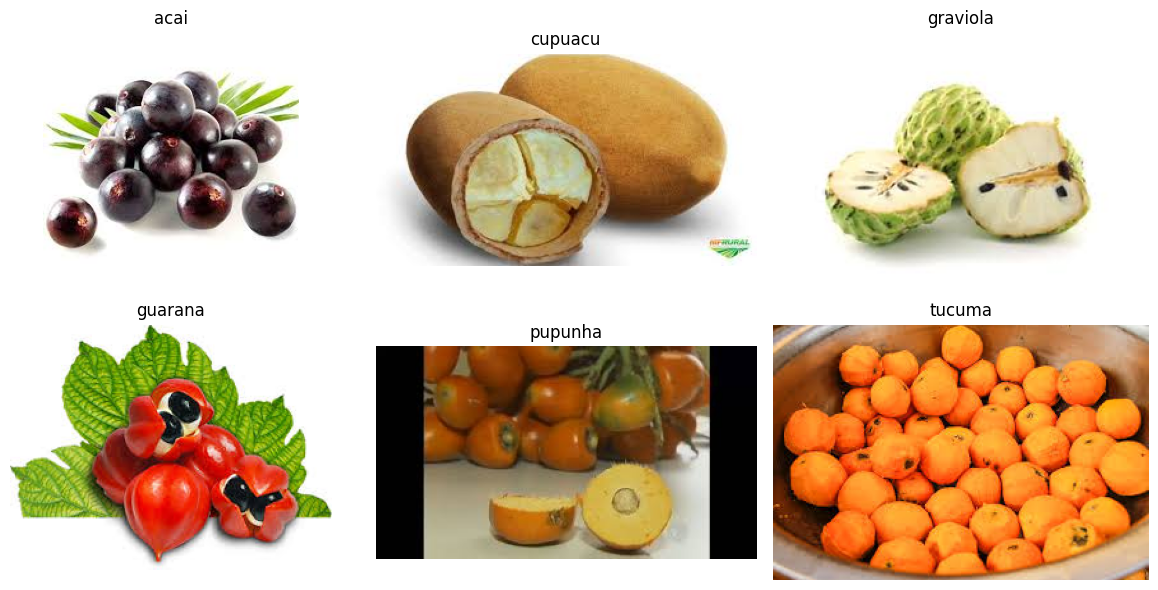

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

#Section 2.2
## Step 6: Data Generation

use Keras utility to load images from directory and split them into training and validation datasets.
use 20% of the training data as validation data.

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Parameters
image_size = (128, 128)   # safer than 28 for your dataset
batch_size = 32

# Load dataset
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


## Step 7: Understanding Dataset Shape

The dataset is loaded as batches of images and labels.
inspect the shape of images and labels.

In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


## Step 8: Visualizing Training Dataset

display a batch of images from the training dataset to verify correctness.


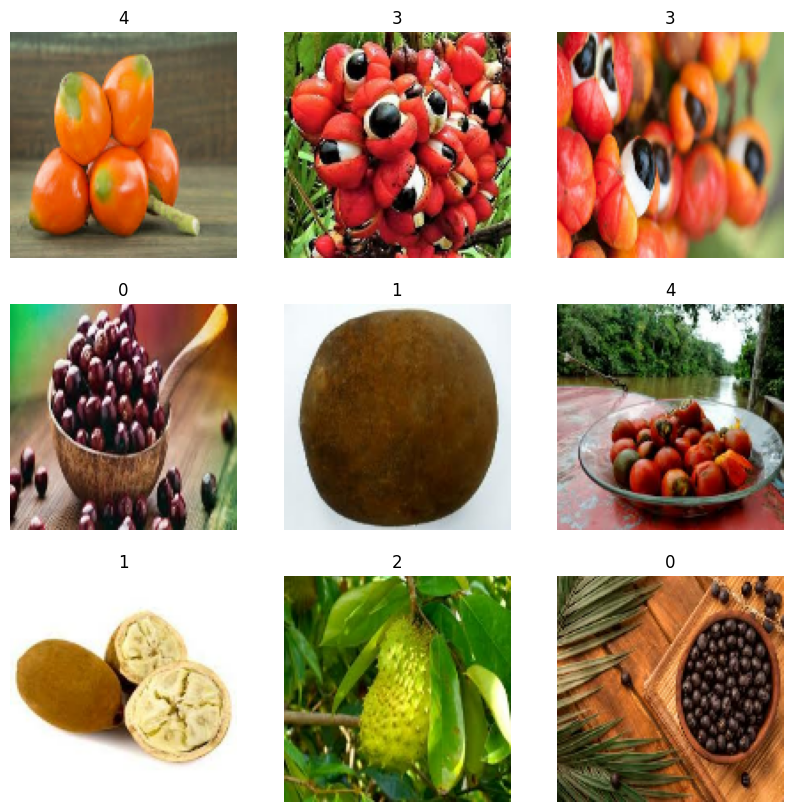

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## Step 9: Data Augmentation

Data augmentation is used to increase dataset diversity and prevent overfitting.

apply transformations such as flipping and rotation.

In [ ]:
from tensorflow.keras import layers

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

## Step 10: Visualizing Augmented Images

visualize augmented images to see how transformations are applied.

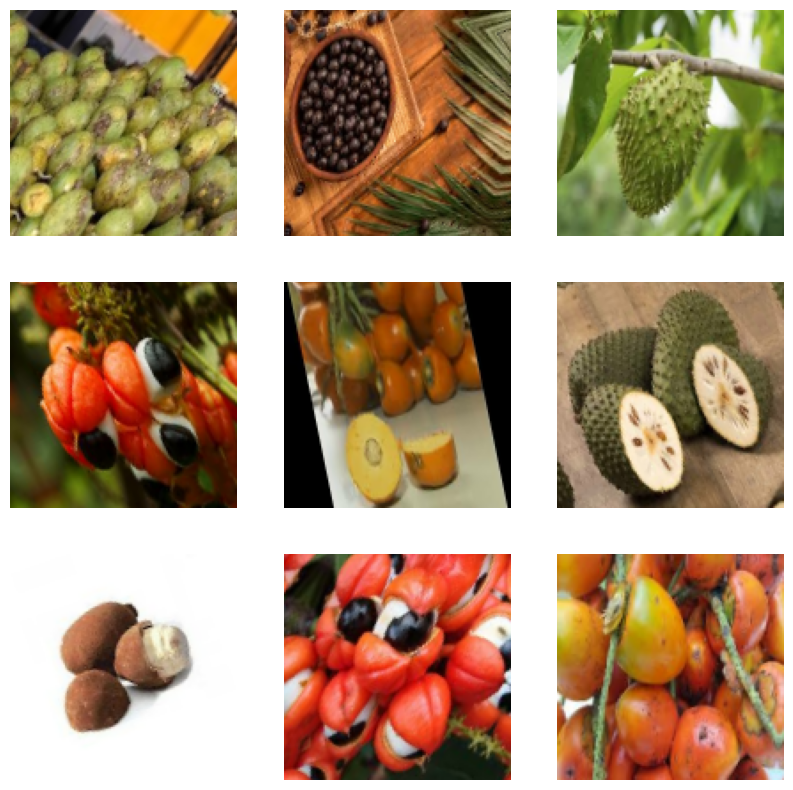

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

## Step 11: Data Preprocessing (Rescaling)

Pixel values range from 0 to 255.

We normalize them to [0,1] for better model performance.

We include rescaling inside the model.

## Step 12: CNN Model Building
build a Convolutional Neural Network (CNN) with:
- Data Augmentation
- Rescaling
- Convolutional Layers
- Batch Normalization
- Dropout

These techniques improve model performance and prevent overfitting.

In [ ]:
from tensorflow.keras import layers, models

# Define model
model = models.Sequential([

    # Data Augmentation
    layers.Lambda(data_augmentation, input_shape=(128, 128, 3)),

    # Rescaling
    layers.Rescaling(1./255),

    # ---- Conv Block 1 ----
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ---- Conv Block 2 ----
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ---- Conv Block 3 ----
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ---- Flatten ----
    layers.Flatten(),

    # ---- Dense Layers ----
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # ---- Output Layer ----
    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Step 13: Model Compilation

compile the model using:
- Adam optimizer
- Sparse categorical crossentropy loss
- Accuracy metric

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 14: Model Summary

display the model architecture to understand the layers and parameters.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           77

 Total params: 4,289,862 (16.36 MB)

 Trainable params: 4,289,158 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

## Step 15: Model Training

train the model using the training dataset and validate using validation dataset.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1806 - loss: 2.5223 - val_accuracy: 0.2222 - val_loss: 2.1464
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4722 - loss: 1.4977 - val_accuracy: 0.2222 - val_loss: 1.8193
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5972 - loss: 1.1093 - val_accuracy: 0.1111 - val_loss: 1.7477
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6806 - loss: 0.8664 - val_accuracy: 0.2222 - val_loss: 1.7434
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6111 - loss: 0.8867 - val_accuracy: 0.2222 - val_loss: 1.7591
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7500 - loss: 0.7211 - val_accuracy: 0.2222 - val_loss: 1.8107
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7222 - loss: 0.8576 - val_accuracy: 0.2222 - val_loss: 1.8805
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7500 - loss: 0.6538 - val_accuracy: 0.2222 - val_loss: 1.9471
Epoch 9/10
3/3 ━

## Step 16: Model Evaluation

evaluate the performance of the model on validation data.

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.2222 - loss: 2.0816
Validation Accuracy: 0.2222


## Step 17: Making Predictions

generate predictions and compare them with actual labels.

In [ ]:
import numpy as np

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    print("Predicted:", predicted_labels[:10])
    print("Actual:   ", labels[:10].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Predicted: [1 1 1 1 1 1 1 1 1 1]
Actual:    [4 4 1 5 1 0 1 5 3 0]


## Step 18: Transfer Learning using VGG16

Transfer learning uses a pre-trained model (VGG16) trained on ImageNet.
reused learned features and adapt the model for our fruit classification task.

In [ ]:
from tensorflow.keras.applications import VGG16

# Load VGG16 without top layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Step 19: Freeze Pre-trained Layers

freeze all layers of the base model so that their weights are not updated during training.
This helps preserve learned features.

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

## Step 20: Add Custom Layers

add new layers on top of the pre-trained model for our classification task.

In [ ]:
from tensorflow.keras import layers

x = base_model.output

# Reduce dimensions
x = layers.GlobalAveragePooling2D()(x)

# Fully connected layer
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output layer
output = layers.Dense(len(class_names), activation='softmax')(x)

## Step 21: Build Final Model

combine the base model and custom layers to create the final model.

In [ ]:
from tensorflow.keras.models import Model

model_vgg = Model(inputs=base_model.input, outputs=output)

## Step 22: Compile Model

compile the model using Adam optimizer and categorical crossentropy loss.

In [ ]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 23: Train Transfer Learning Model

train the model using training data and validate on validation data.

In [ ]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step - accuracy: 0.1528 - loss: 16.7317 - val_accuracy: 0.1667 - val_loss: 8.7111
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 8s/step - accuracy: 0.3611 - loss: 7.9987 - val_accuracy: 0.1667 - val_loss: 7.7692
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.4306 - loss: 5.9638 - val_accuracy: 0.2778 - val_loss: 7.9742
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 10s/step - accuracy: 0.6389 - loss: 3.1734 - val_accuracy: 0.2778 - val_loss: 7.6277
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.7778 - loss: 1.6308 - val_accuracy: 0.2222 - val_loss: 6.9220
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.8056 - loss: 1.3693 - val_accuracy: 0.2778 - val_loss: 6.4548
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.7917 - loss: 1.8368 - val_accuracy: 0.2778 - val_loss: 6.5235
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 8s/step - accuracy: 0.8472 - loss: 0.8488 - val_accuracy: 0.2778 - val_loss: 6.9799
Epoch 

## Step 24: Evaluate Model

evaluate the performance of the transfer learning model.

In [ ]:
loss, accuracy = model_vgg.evaluate(val_ds)
print(f"Validation Accuracy (VGG16): {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3333 - loss: 8.4457
Validation Accuracy (VGG16): 0.3333


## Step 25: Classification Report

generate predictions and evaluate model performance using classification report.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       1.00      0.50      0.67         4
    graviola       0.33      1.00      0.50         1
     guarana       0.20      1.00      0.33         1
     pupunha       0.17      0.25      0.20         4
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.33        18
   macro avg       0.45      0.49      0.34        18
weighted avg       0.57      0.33      0.33        18

